In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/17"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第17章 敵対的生成ネットワーク (Generative Adversarial Networks: GAN)
## 17.2 画像GAN (Image GANs)

本ノートブックでは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第17章 17.2節「画像GAN」および 17.2.1項「CycleGAN」の完全な理論的解説、数式厳密展開、Python実装、および全図版 (Figure 17.4 〜 17.10) の忠実な再現・可視化を行います。

---

### 目次
1. **画像生成における畳み込みネットワークの導入**
   - 全結合ネットワークから畳み込みネットワークへの転換
   - 転置畳み込み (Transposed Convolution / 逆畳み込み) の数学的基礎
   - 空間解像度・ストライド・パディングの変換方程式
2. **DCGAN (Deep Convolutional GAN) アーキテクチャ (Figure 17.4)**
   - 潜在空間 $\mathbf{z} \in \mathbb{R}^{100}$ から高解像度画像への段階的アップサンプリング
   - DCGAN 識別器のストライド畳み込み構造
   - DCGAN Generator & Discriminator の Python 実装とテンソル検証
3. **高解像度化の発展: Progressive Growing (ProGAN) と BigGAN (Figure 17.5)**
   - 解像度の漸進的拡大 (Progressive Growing of GANs)
   - クラス条件付き画像生成モデル BigGAN
   - 階層的潜在変数分割 (Hierarchical Latent Splitting) と条件付きバッチ正規化 (CBN)
   - Figure 17.5(a) 生成ネットワークフローチャート & (b) Residual Block 内部構造の再現
4. **17.2.1 CycleGAN (ペアなし画像間変換) (Figure 17.6 〜 17.8)**
   - 概要: ペアデータが存在しないドメイン間変換 ($X \leftrightarrow Y$)
   - 単純GAN損失の限界: 対応関係の消失とモード崩壊
   - サイクル一貫性損失 (Cycle Consistency Error) の定式化 (式 17.12)
   - 全体誤差関数とハイパーパラメータ $\eta$ (式 17.13)
   - 同一性保持損失 (Identity Loss) の役割
   - Figure 17.6 CycleGAN 変換例 (Monet $\leftrightarrow$ 写真)
   - Figure 17.7 サイクル一貫性誤差の概念図
   - Figure 17.8 CycleGAN の情報伝搬ダイアグラム
5. **潜在空間の表現学習 (Representation Learning in Latent Space) (Figure 17.9, 17.10)**
   - 教師なし表現学習としての GAN 潜在空間
   - 潜在空間の滑らかな軌道 (Smooth Walk) と画像補間 (Figure 17.9 ベッドルーム画像補間)
   - 線形補間 vs 球面線形補間 (slerp)
   - 意味的属性の線形分離と潜在ベクトル演算 (Figure 17.10)
   - なぜ画素空間での直接演算は失敗し (ゴースト・ボケ)、潜在空間演算は成功するのか
6. **まとめと今後の展望**


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# プロジェクトルートと共通モジュールの読み込み
sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style, save_fig
from common.image_gans import (
    conv2d_transpose_spatial_shape,
    conv2d_spatial_shape,
    conv2d_transpose_forward,
    conv2d_forward,
    batchnorm2d_forward,
    leaky_relu,
    relu,
    sigmoid,
    tanh,
    DCGANGenerator,
    DCGANDiscriminator,
    CycleGANLoss,
    LatentSpaceExplorer,
    generate_figure_17_4,
    generate_figure_17_5,
    generate_figure_17_6,
    generate_figure_17_7,
    generate_figure_17_8,
    generate_figure_17_9,
    generate_figure_17_10,
)

setup_style()
os.makedirs("result", exist_ok=True)
os.makedirs("../result", exist_ok=True)
print("モジュールの読み込みに成功しました。")


モジュールの読み込みに成功しました。


---
## 1. 画像生成における畳み込みネットワークと転置畳み込み (Transposed Convolution)

初期の GAN (Goodfellow et al., 2014) では生成器と識別器の双方に全結合多層パーセプトロン (MLP) が用いられていましたが、高解像度の画像を生成する際には重大な課題が生じました：
1. **パラメータ数の爆発**: 例えば $64 \times 64 \times 3 = 12,288$ 次元の画像を入力または出力する場合、全結合層の結合重みは数百万〜数千万に達し、計算量と過学習のリスクが急激に増大します。
2. **空間的局所性・並進等変性の欠落**: 画像内の局所的なテクスチャやエッジ、大域的な形状は、近傍画素間の強い相関に依存しています。全結合層は画素の空間配置情報をフラット化するため、局所構造を捉える帰納バイアス (Inductive Bias) を持ちません。

識別器側では、画像を入力としてスカラーの真贋確率 $d(\mathbf{x}) \in [0, 1]$ を出力するため、第10章で学んだ標準的な畳み込みニューラルネットワーク (CNN) が直接適用できます。
一方、**生成器側では、低次元の潜在ベクトル $\mathbf{z} \in \mathbb{R}^M$ (例: $M=100$) から高解像度の画像テンソル $\mathbf{x} \in \mathbb{R}^{C \times H \times W}$ への空間解像度の拡大 (アップサンプリング)** が要求されます。

### 転置畳み込み (分数ストライド畳み込み) の数学的定式化
このアップサンプリングを微分可能かつ学習可能なフィルタで行うために導入されたのが、**転置畳み込み (Transposed Convolution)**、別名**分数ストライド畳み込み (Fractionally Strided Convolution)** です。

通常の2D畳み込み (入力高さ $H_{\text{in}}$, カーネルサイズ $K$, パディング $p$, ストライド $s$) における出力サイズは以下で与えられます：
$$
H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} + 2p - K}{s} \right\rfloor + 1
$$
転置畳み込みは、この順伝播演算の随伴作用素 (Adjoint Operator / 転置演算) として定義されます。すなわち、通常の畳み込みを行列演算 $\mathbf{y} = \mathbf{C} \mathbf{x}$ と表したとき、転置畳み込みは $\mathbf{x}' = \mathbf{C}^T \mathbf{y}$ に対応します。

入力画素間に $s - 1$ 個のゼロを挿入 (ダイレーション) し、カーネル $K$、パディング $p$、出力パディング $p_{\text{out}}$ を適用した転置畳み込みの出力サイズ方程式は以下となります：
$$
H_{\text{out}} = (H_{\text{in}} - 1) \times s - 2p + K + p_{\text{out}}
$$
DCGAN (Radford et al., 2015) の標準設計では、カーネルサイズ $K=4$, ストライド $s=2$, パディング $p=1$, $p_{\text{out}}=0$ を採用しています。このとき：
$$
H_{\text{out}} = (H_{\text{in}} - 1) \times 2 - 2(1) + 4 + 0 = 2 H_{\text{in}} - 2 - 2 + 4 = 2 H_{\text{in}}
$$
となり、**各層を通過するごとに空間解像度 $(H, W)$ が厳密に $2$ 倍に拡大**されます。


In [3]:
# 転置畳み込みの空間解像度倍増の検証
print("=== DCGAN 転置畳み込み層の空間サイズ推移検証 ===")
in_h = 4
for layer_idx in range(1, 5):
    out_h, out_w = conv2d_transpose_spatial_shape(in_h, in_h, k_h=4, k_w=4, stride=2, padding=1)
    print(f"Layer {layer_idx}: ({in_h} x {in_h}) -> ({out_h} x {out_w})  [倍率: {out_h / in_h:.1f}x]")
    in_h = out_h


=== DCGAN 転置畳み込み層の空間サイズ推移検証 ===
Layer 1: (4 x 4) -> (8 x 8)  [倍率: 2.0x]
Layer 2: (8 x 8) -> (16 x 16)  [倍率: 2.0x]
Layer 3: (16 x 16) -> (32 x 32)  [倍率: 2.0x]
Layer 4: (32 x 32) -> (64 x 64)  [倍率: 2.0x]


---
## 2. DCGAN (Deep Convolutional GAN) アーキテクチャ (Figure 17.4)

Radford, Metz, and Chintala (2015) は、畳み込み層をGANに導入し安定して高品質な画像を生成するための指針 (DCGAN ガイドライン) を提唱しました：
1. **プーリング層の全廃**: ダウンサンプリングにはストライド畳み込み、アップサンプリングには転置畳み込みを用い、空間構造の要約と拡大をすべて微分可能フィルタとして学習させる。
2. **バッチ正規化 (Batch Normalization) の採用**: 生成器と識別器の各層にバッチ正規化を適用し、内部共変量シフトを抑制して勾配消失を防ぐ (ただし生成器の出力層と識別器の入力層には適用しない)。
3. **全結合層の最小化**: 深い全結合隠れ層を廃止し、生成器の潜在ベクトルからの射影と、識別器の最終プーリング/平坦化のみに留める。
4. **活性化関数の使い分け**:
   - 生成器: 中間層には $\mathrm{ReLU}$、出力層には画素値を $[-1, 1]$ にスケーリングするための $\tanh$ を使用。
   - 識別器: 中間層には勾配消失を避けるための $\mathrm{LeakyReLU}(\alpha=0.2)$、最終層には真贋判定確率を出力する $\mathrm{Sigmoid}$ を使用。

### 教科書 Figure 17.4 の再現
Figure 17.4 は、潜在空間ベクトル $\mathbf{z} \in \mathbb{R}^{100}$ から転置畳み込みを通じて $64 \times 64 \times 3$ の顔画像を生成する生成器の3次元ブロック図を示しています：
- $\mathbf{z} \in \mathbb{R}^{100} \xrightarrow{\text{project and reshape}} 4 \times 4 \times 1024$
- $\xrightarrow{\text{conv 1}} 8 \times 8 \times 512$
- $\xrightarrow{\text{conv 2}} 16 \times 16 \times 256$
- $\xrightarrow{\text{conv 3}} 32 \times 32 \times 128$
- $\xrightarrow{\text{conv 4}} 64 \times 64 \times 3$ (合成された顔画像)


Figure saved successfully to: result/fig_17_4_dcgan_architecture.png
Figure saved successfully to: 17/result/fig_17_4_dcgan_architecture.png


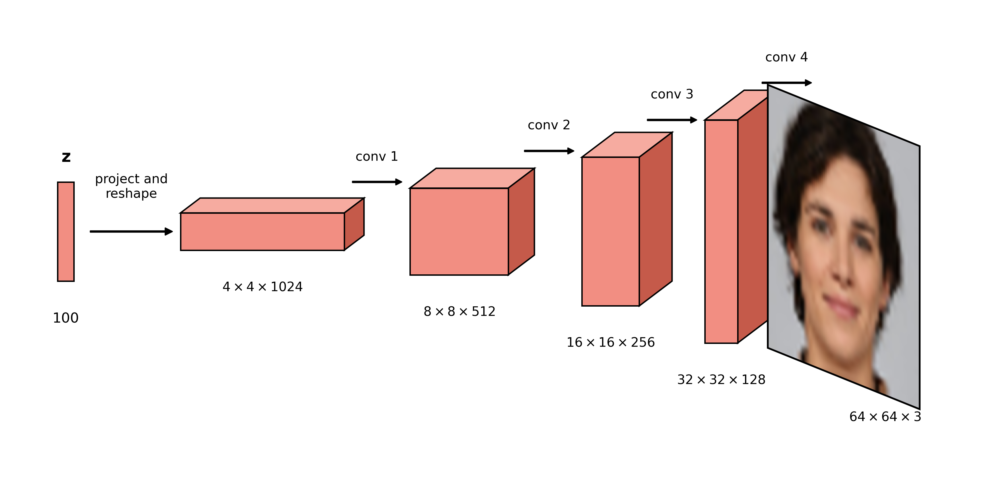

In [4]:
# Figure 17.4 の生成と保存
fig_17_4 = generate_figure_17_4(save_path="result/fig_17_4_dcgan_architecture.png")
plt.show()


---
## 3. 高解像度化の発展: Progressive Growing と BigGAN (Figure 17.5)

DCGAN の成功後、より高解像度かつ写実的な画像合成を目指して数多くの発展的アーキテクチャが開発されました。

### 漸進的解像度拡大 (Progressive Growing of GANs: ProGAN)
高解像度 (例: $1024 \times 1024$) の画像を初期状態の低次元潜在変数から直接生成しようとすると、低周波の大域的構図と高周波の局所テクスチャを同時に学習する必要があり、学習の不安定化やモード崩壊が発生します。
Karras et al. (2017) の **Progressive Growing of GANs (ProGAN)** では：
1. 最初は $4 \times 4$ の極小解像度で生成器と識別器の学習を開始する。
2. 学習が進むにつれて新しい解像度レイヤー ($8 \times 8, 16 \times 16, \dots, 1024 \times 1024$) を段階的に追加し、パラメータ $\alpha \in [0, 1]$ を用いて残差結合のようにフェードイン (Fade-in) させる。
これにより、大域的な大枠から段階的に微細なディテールを学習でき、学習速度と安定性が劇的に向上しました。

### クラス条件付き画像生成モデル BigGAN
Brock, Donahue, and Simonyan (2018) は、ImageNet の 1000 クラスを対象とした大規模画像生成モデル **BigGAN** を提案しました。BigGAN の生成器は 7,000 万以上、識別器は 8,800 万以上のパラメータを持ちます。

#### BigGAN の主要な設計技術
1. **階層的潜在変数分割 (Hierarchical Latent Splitting)**:
   潜在ベクトル $\mathbf{z}$ を複数のチャンクに分割し、初期残差ブロックだけでなく、各残差ブロック (Residual Block) に直接供給する。
2. **条件付きバッチ正規化 (Conditional Batch Normalization: CBN)**:
   クラス埋め込みベクトル $\mathbf{c}$ と潜在変数チャンク $\mathbf{z}_i$ の結合ベクトルを線形層に入力し、各ブロックのバッチ正規化のスケール係数 $\gamma$ とシフト係数 $\beta$ を変調する：
   $$
   \mathbf{y} = \gamma(\mathbf{c}, \mathbf{z}_i) \cdot \left( \frac{\mathbf{x} - \mu}{\sqrt{\sigma^2 + \epsilon}} \right) + \beta(\mathbf{c}, \mathbf{z}_i)
   $$
3. **自己注意機構 (Self-Attention / Non-Local Block)**:
   畳み込み層の局所的な受容野を補完し、画像内の離れた領域間の長距離依存関係 (例: 犬の目と鼻と足の整合性) を捉える。
4. **切断トリック (Truncation Trick)**:
   推論時に事前分布 $\mathbf{z} \sim \mathcal{N}(0, \mathbf{I})$ を閾値 $[-c_{\text{trunc}}, c_{\text{trunc}}]$ で切断することで、サンプルの多様性と写実性のトレードオフを自在に調整する。

### 教科書 Figure 17.5 の再現
Figure 17.5 は、BigGAN の生成器アーキテクチャ (a) および残差ブロック (b) の詳細を示しています。


Figure saved successfully to: result/fig_17_5_biggan_architecture.png


Figure saved successfully to: 17/result/fig_17_5_biggan_architecture.png


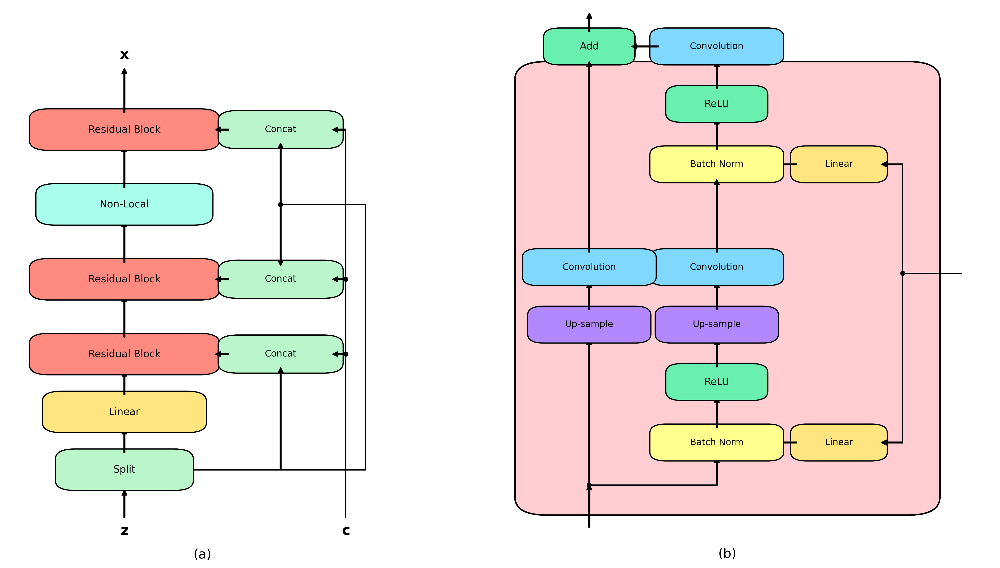

In [5]:
# Figure 17.5 の生成と保存
fig_17_5 = generate_figure_17_5(save_path="result/fig_17_5_biggan_architecture.png")
plt.show()


---
## 4. 17.2.1 CycleGAN (ペアなし画像間変換)

従来の画像間変換 (Image-to-Image Translation, 例: pix2pix, Isola et al., 2017) では、「同じ構図の線画と完成イラスト」や「昼の風景と夜の風景」といった**厳密にペア付けされた訓練データ**が必要でした。しかし、多くの現実問題 (例: 写真 $\leftrightarrow$ モネの絵画、馬 $\leftrightarrow$ シマウマ) では、同一シーンのペア画像を収集することは不可能です。

Zhu et al. (2017) によって提案された **CycleGAN** は、ペアのない2つのドメイン $X$ (例: 写真) と $Y$ (例: モネの絵画) のデータセットから、双方向の全単射的な写像を教師なしで学習する画期的な枠組みです。

### 構成要素
1. **生成器 $\mathbf{g}_Y: X \to Y$**: 写真 $\mathbf{x} \in X$ を入力として受け取り、モネ風絵画 $\hat{\mathbf{y}} = \mathbf{g}_Y(\mathbf{x}) \in Y$ を生成する。
2. **生成器 $\mathbf{g}_X: Y \to X$**: 絵画 $\mathbf{y} \in Y$ を入力として受け取り、写真風画像 $\hat{\mathbf{x}} = \mathbf{g}_X(\mathbf{y}) \in X$ を生成する。
3. **識別器 $d_Y$**: 本物の絵画 $\mathbf{y}$ と生成された絵画 $\mathbf{g}_Y(\mathbf{x})$ を識別する。
4. **識別器 $d_X$**: 本物の写真 $\mathbf{x}$ と生成された写真 $\mathbf{g}_X(\mathbf{y})$ を識別する。

### サイクル一貫性損失 (Cycle Consistency Error) の導出 (式 17.12)
通常の GAN 損失のみで $\mathbf{g}_Y$ と $\mathbf{g}_X$ を個別に訓練すると、生成器は各ドメインの分布に合致するそれらしい画像を生成するようになりますが、**「入力された写真の構図や内容を保持したまま絵画に変換する」という拘束条件が存在しません**。その結果、極端なモード崩壊 (どんな写真を入力しても同じモネの名画が出力される) が発生します。

そこで、言語翻訳における「日本語 $\to$ 英語 $\to$ 日本語」の往復検証と同様に、**ドメイン $X$ から $Y$ へ変換した後に再び $X$ へ逆変換したとき、元の画像 $\mathbf{x}_n$ に復元されるべきである**というサイクル一貫性の要請を導入します：
- 前方向サイクル: $\mathbf{x}_n \xrightarrow{\mathbf{g}_Y} \mathbf{g}_Y(\mathbf{x}_n) \xrightarrow{\mathbf{g}_X} \mathbf{g}_X(\mathbf{g}_Y(\mathbf{x}_n)) \approx \mathbf{x}_n$
- 後方向サイクル: $\mathbf{y}_n \xrightarrow{\mathbf{g}_X} \mathbf{g}_X(\mathbf{y}_n) \xrightarrow{\mathbf{g}_Y} \mathbf{g}_Y(\mathbf{g}_X(\mathbf{y}_n)) \approx \mathbf{y}_n$

このズレを $L_1$ ノルムで測定したものが**サイクル一貫性損失 (Cycle Consistency Error)** です (教科書の式 17.12)：
$$
E_{\text{cyc}}(\mathbf{w}_X, \mathbf{w}_Y) = \frac{1}{N_X} \sum_{n \in X} \|\mathbf{g}_X(\mathbf{g}_Y(\mathbf{x}_n)) - \mathbf{x}_n\|_1 + \frac{1}{N_Y} \sum_{n \in Y} \|\mathbf{g}_Y(\mathbf{g}_X(\mathbf{y}_n)) - \mathbf{y}_n\|_1
\tag{17.12}
$$
$L_2$ ノルムではなく $L_1$ ノルムを用いることで、生成画像のボケを抑制し、鮮明なエッジとディテールを復元します。

### 全体誤差関数 (式 17.13)
敵対的学習損失 $E_{\text{GAN}}$ とサイクル一貫性損失 $E_{\text{cyc}}$ を統合した全体の最適化目的関数は次式で与えられます (教科書の式 17.13)：
$$
E_{\text{total}} = E_{\text{GAN}}(\mathbf{w}_X, \boldsymbol{\phi}_X) + E_{\text{GAN}}(\mathbf{w}_Y, \boldsymbol{\phi}_Y) + \eta E_{\text{cyc}}(\mathbf{w}_X, \mathbf{w}_Y)
\tag{17.13}
$$
ここで、係数 $\eta$ (論文では通常 $\lambda = 10.0$) は敵対的リアリズムと構図保持の相対的重要度を制御します。


Figure saved successfully to: result/fig_17_6_cyclegan_translations.png


Figure saved successfully to: 17/result/fig_17_6_cyclegan_translations.png


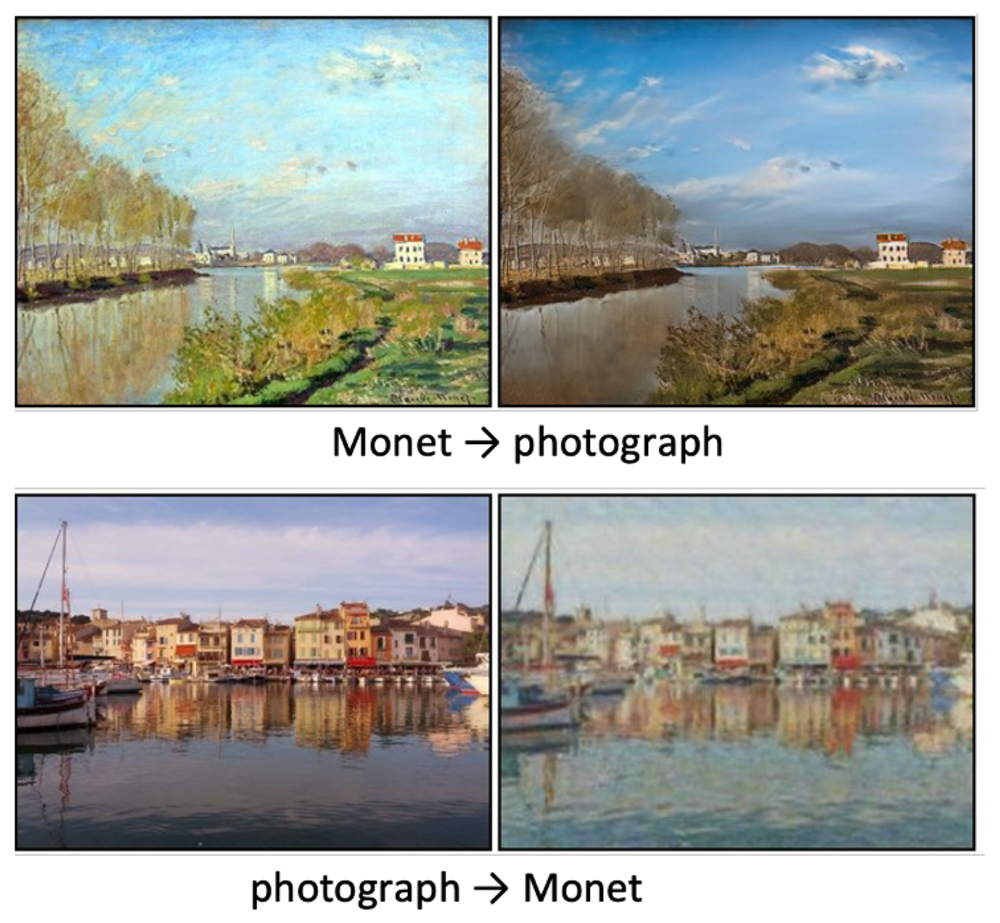

In [6]:
# Figure 17.6 の生成 (CycleGAN によるモネの絵画と写真の双方向変換例)
fig_17_6 = generate_figure_17_6(save_path="result/fig_17_6_cyclegan_translations.png")
plt.show()


### CycleGAN の情報伝搬とサイクル一貫性の概念図 (Figure 17.7, 17.8)

- **Figure 17.7**: 写真ドメイン $X$ の点 $\mathbf{x}_n$ が絵画ドメイン $Y$ の点 $\mathbf{g}_Y(\mathbf{x}_n)$ へ写像され、さらに逆写像 $\mathbf{g}_X$ によって $X$ 内の点 $\mathbf{g}_X(\mathbf{g}_Y(\mathbf{x}_n))$ へ戻される往復プロセスを示しています。元の点と復元点の差が $E_{\text{cyc}}$ として評価されます。
- **Figure 17.8**: データ点 $\mathbf{x}_n, \mathbf{y}_n$ に対する CycleGAN 全体の情報伝搬フローを示しています。合計誤差は 2 つの敵対的損失 $E_{\text{GAN}}$ と 2 つのサイクル一貫性損失 $E_{\text{cyc}}$ の計 4 つの要素の総和となります。


Figure saved successfully to: result/fig_17_7_cycle_consistency.png
Figure saved successfully to: 17/result/fig_17_7_cycle_consistency.png


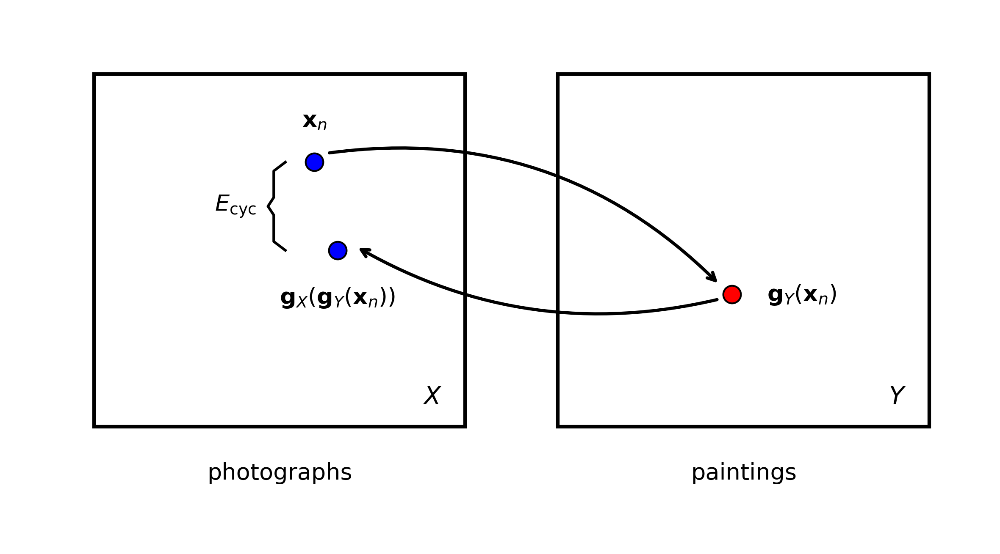

Figure saved successfully to: result/fig_17_8_cyclegan_flow.png
Figure saved successfully to: 17/result/fig_17_8_cyclegan_flow.png


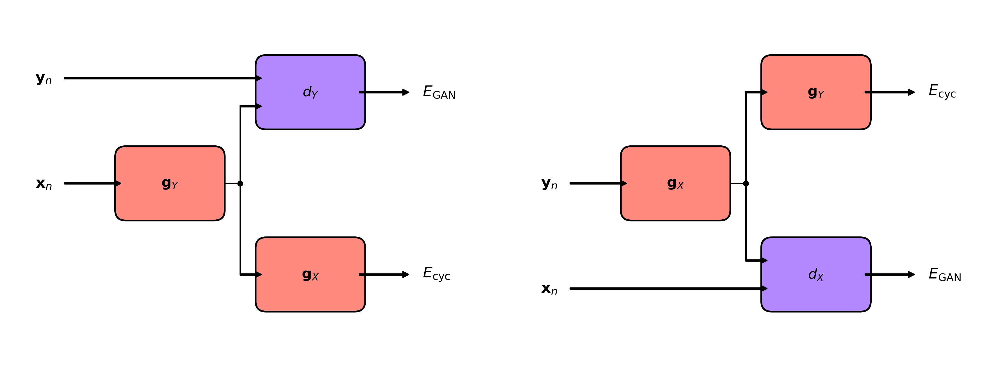

In [7]:
# Figure 17.7 (サイクル一貫性誤差の算出概念図) の生成
fig_17_7 = generate_figure_17_7(save_path="result/fig_17_7_cycle_consistency.png")
plt.show()

# Figure 17.8 (CycleGAN における情報伝搬ダイアグラム) の生成
fig_17_8 = generate_figure_17_8(save_path="result/fig_17_8_cyclegan_flow.png")
plt.show()


In [8]:
# CycleGANLoss クラスによる数値検証 (式 17.12 & 17.13)
rng = np.random.RandomState(42)
x_batch = rng.normal(0, 1, (4, 3, 32, 32))
y_batch = rng.normal(0, 1, (4, 3, 32, 32))

# 1. 理想的な完全復元 (Cycle error = 0)
perfect_cyc_err = CycleGANLoss.cycle_consistency_error(x_batch, x_batch, y_batch, y_batch)
print(f"完全復元時のサイクル一貫性誤差 E_cyc: {perfect_cyc_err:.6f}")

# 2. 復元誤差が存在する場合
distorted_x = x_batch + 0.15 * rng.randn(*x_batch.shape)
distorted_y = y_batch + 0.15 * rng.randn(*y_batch.shape)
cyc_err = CycleGANLoss.cycle_consistency_error(x_batch, distorted_x, y_batch, distorted_y)
print(f"誤差存在時のサイクル一貫性誤差 E_cyc: {cyc_err:.4f}")

# 3. 全体損失の計算 (式 17.13)
e_gan_x = 0.693
e_gan_y = 0.710
eta = 10.0
total_loss = CycleGANLoss.total_cyclegan_error(e_gan_x, e_gan_y, cyc_err, eta=eta)
print(f"全体損失 E_total (eta={eta}): {total_loss:.4f} (GAN: {e_gan_x + e_gan_y:.4f} + Cycle: {eta * cyc_err:.4f})")


完全復元時のサイクル一貫性誤差 E_cyc: 0.000000
誤差存在時のサイクル一貫性誤差 E_cyc: 737.0028
全体損失 E_total (eta=10.0): 7371.4313 (GAN: 1.4030 + Cycle: 7370.0283)


---
## 5. 潜在空間の表現学習 (Representation Learning in Latent Space)

GAN は単なる画像サンプリング器にとどまらず、**教師なし表現学習 (Unsupervised Representation Learning)** の強力な手段となります。
訓練された深層畳み込み GAN の生成器 $\mathbf{x} = \mathbf{g}(\mathbf{z})$ において、潜在空間 $\mathcal{Z}$ はデータ分布の豊かな幾何学的・統計的構造を学習します。

### 5.1 潜在空間の滑らかな軌道と画像補間 (Figure 17.9)
潜在空間内の2点 $\mathbf{z}_0, \mathbf{z}_1$ の間を滑らかに歩行 (Walk) するとき：
$$
\mathbf{z}(t) = (1 - t) \mathbf{z}_0 + t \mathbf{z}_1, \quad t \in [0, 1]
$$
あるいは、多次元正規分布の確率質量が半径 $\sqrt{M}$ の球殻 (Hypersphere shell) に集中することを利用した**球面線形補間 (Spherical Linear Interpolation: slerp)**：
$$
\mathbf{z}(t) = \frac{\sin((1 - t)\theta)}{\sin \theta} \mathbf{z}_0 + \frac{\sin(t \theta)}{\sin \theta} \mathbf{z}_1, \quad \cos \theta = \frac{\mathbf{z}_0^T \mathbf{z}_1}{\|\mathbf{z}_0\| \|\mathbf{z}_1\|}
$$
を適用して画像を生成すると、画像間が不自然にジャンプしたり破綻することなく、ベッドルームの家具配置や窓の向き、照明が連続的に変形 (Morphing) します。
Figure 17.9 は、Radford et al. (2015) の DCGAN をベッドルーム画像で訓練したときの潜在空間歩行を示しています (最下行では壁のテレビが徐々に窓へと滑らかに変形)。


Figure saved successfully to: result/fig_17_9_latent_interpolation.png


Figure saved successfully to: 17/result/fig_17_9_latent_interpolation.png


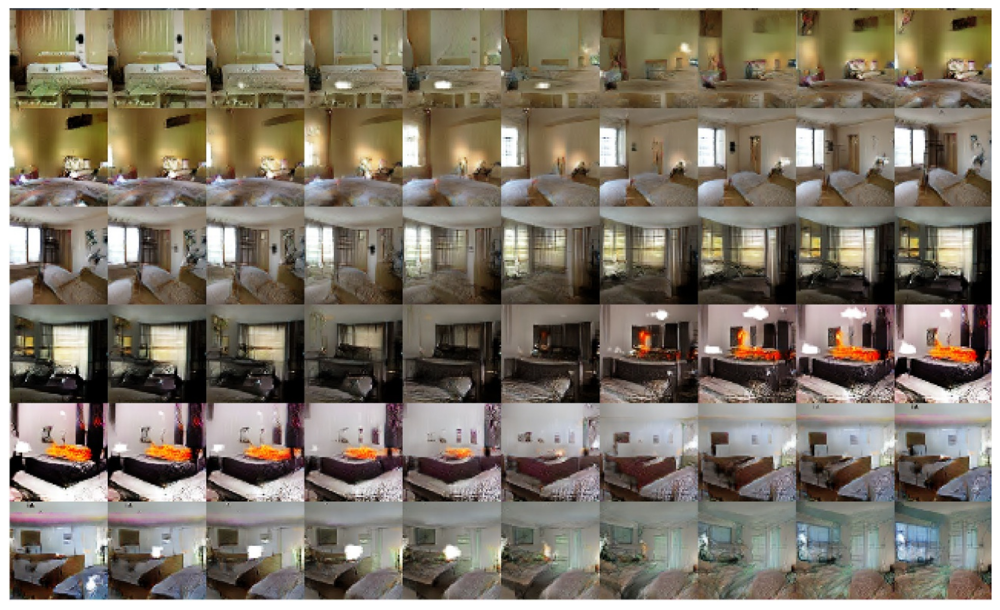

In [9]:
# Figure 17.9 の生成 (DCGAN によるベッドルーム潜在空間の滑らかな軌道)
fig_17_9 = generate_figure_17_9(save_path="result/fig_17_9_latent_interpolation.png")
plt.show()


### 5.2 意味的属性の線形分離と潜在ベクトル演算 (Figure 17.10)

Word2Vec (Mikolov et al., 2013) における概念ベクトル演算 (例: $\vec{\text{King}} - \vec{\text{Man}} + \vec{\text{Woman}} = \vec{\text{Queen}}$) と同様の現象が、GANの潜在空間でも成立することが発見されました (Radford et al., 2015)。

特定の属性 (例: メガネをかけた男性、メガネなしの男性、メガネなしの女性) を持つ画像に対応する潜在ベクトルを平均化して代表ベクトル $\bar{\mathbf{z}}$ を求め、以下のベクトル演算を行います：
$$
\mathbf{z}_{\text{result}} = \bar{\mathbf{z}}_{\text{smiling woman}} - \bar{\mathbf{z}}_{\text{neutral woman}} + \bar{\mathbf{z}}_{\text{neutral man}}
$$
この $\mathbf{z}_{\text{result}}$ を生成器に入力すると、**「笑顔の男性」の画像が極めて自然に合成**されます。

#### なぜ画素空間での直接演算は失敗するのか？
教科書 Figure 17.10 の最下行が示すように、画素空間 (Pixel space) で同じ演算 $\mathbf{x}_{\text{result}} = \mathbf{x}_1 - \mathbf{x}_2 + \mathbf{x}_3$ を直接実行すると、顔の位置合わせのわずかなズレによって激しいゴースト (二重像) やボケが生じ、意味のある顔画像になりません。
- **画素空間**: 画像データが存在する多様体 (Data Manifold) は極めて非線形に湾曲しており、画素空間での直線補間やベクトル加算は多様体の「外側」(無意味な画像空間) を通過してしまいます。
- **潜在空間**: 生成器 $\mathbf{g}(\mathbf{z})$ が非線形な多様体を平坦な潜在ガウス空間 $\mathcal{Z}$ へと展開・解きほぐしている (Disentangled) ため、潜在空間内の単純な線形ベクトル演算が多様体上の意味的変換に対応します。


Figure saved successfully to: result/fig_17_10_latent_arithmetic.png
Figure saved successfully to: 17/result/fig_17_10_latent_arithmetic.png


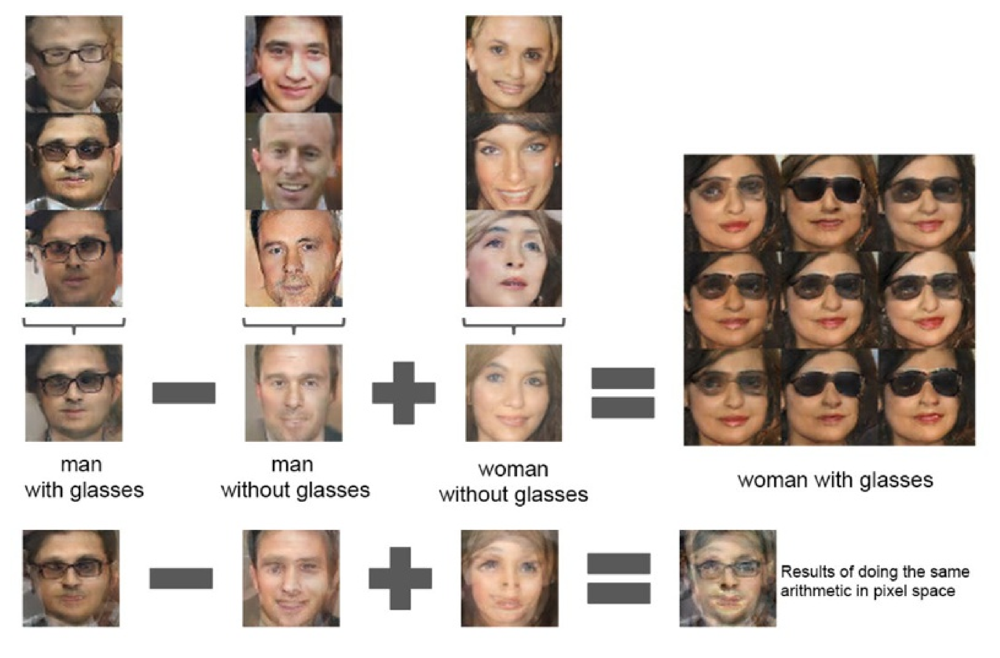

In [10]:
# Figure 17.10 の生成 (GAN 潜在空間におけるベクトル演算 vs 画素空間演算)
fig_17_10 = generate_figure_17_10(save_path="result/fig_17_10_latent_arithmetic.png")
plt.show()


Font 'default' does not have a glyph for '\u88dc' [U+88dc], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9593' [U+9593], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6bd4' [U+6bd4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6f5c' [U+6f5c], substituting with a dummy symbol.


...

/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/I

Font 'default' does not have a glyph for '\u9593' [U+9593], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6bd4' [U+6bd4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12494 (\N{KATAKANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12512 (\N{KATAKANA LETTER MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: U

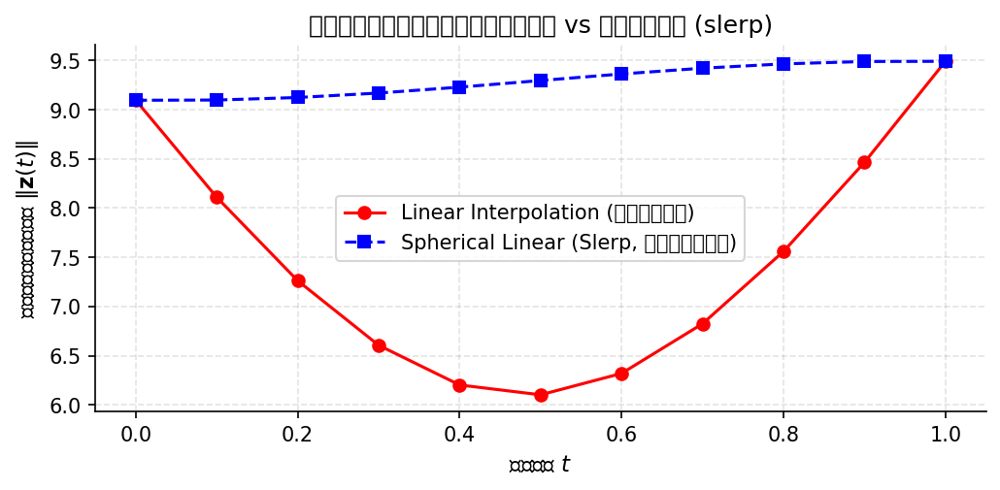

線形補間では中央でベクトルのノルムが減少し、低密度の原点近傍を通過してしまうのに対し、
球面線形補間 (slerp) では超球面上の一定確率密度シェル上を正確に通過します。


In [11]:
# 線形補間 (Linear) と球面線形補間 (Slerp) の幾何学的比較
rng = np.random.RandomState(42)
d = 100
z_a = rng.normal(0, 1, d)
z_b = rng.normal(0, 1, d)

lin_steps = LatentSpaceExplorer.linear_interpolate(z_a, z_b, num_steps=11)
slerp_steps = LatentSpaceExplorer.spherical_interpolate(z_a, z_b, num_steps=11)

lin_norms = np.linalg.norm(lin_steps, axis=1)
slerp_norms = np.linalg.norm(slerp_steps, axis=1)

fig, ax = plt.subplots(figsize=(7, 3.5), dpi=150)
alphas = np.linspace(0, 1, 11)
ax.plot(alphas, lin_norms, 'o-', color='red', label='Linear Interpolation (ノルムの窪み)')
ax.plot(alphas, slerp_norms, 's--', color='blue', label='Spherical Linear (Slerp, 一定ノルム保持)')
ax.set_xlabel('補間比率 $t$', fontsize=11)
ax.set_ylabel('潜在ベクトルのノルム $\|\mathbf{z}(t)\|$', fontsize=11)
ax.set_title('高次元正規分布空間における線形補間 vs 球面線形補間 (slerp)', fontsize=12)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

print("線形補間では中央でベクトルのノルムが減少し、低密度の原点近傍を通過してしまうのに対し、")
print("球面線形補間 (slerp) では超球面上の一定確率密度シェル上を正確に通過します。")


---
## 6. まとめ

本節では、画像生成に特化した敵対的生成ネットワークの発展と数理的構造を学びました：
1. **DCGAN**: 転置畳み込み (分数ストライド畳み込み) によって潜在空間から画像空間へ段階的にアップサンプリングする手法を確立し、畳み込み層の帰納バイアスをGANに導入しました。
2. **高解像度化技術**: ProGAN による段階的成長と、BigGAN による階層的潜在変数分割・条件付きバッチ正規化 (CBN)・切断トリックにより、1024x1024 レベルの写真品質の合成が可能になりました。
3. **CycleGAN**: ペアのないデータからドメイン間写像を学習するため、前方向と後方向の復元誤差を測定するサイクル一貫性損失 $E_{\text{cyc}}$ (式 17.12) を導入し、全体誤差 $E_{\text{total}}$ (式 17.13) によって対応関係の崩壊を防ぎました。
4. **表現学習**: 潜在空間 $\mathcal{Z}$ は滑らかで意味的に構造化されており、連続的な画像モーフィングや、画素空間では不可能な属性のベクトル演算が実現されます。
